In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.lines import Line2D

# =========================
# Figure setup
# =========================
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'dejavuserif',
})

fig, axs = plt.subplots(3, 4, figsize=(16, 11))

placeholder_path = r'D:\CodeWork\python\data_dependency\PGM_dp\utils\placeholder.png'
placeholder_img = mpimg.imread(placeholder_path)

titles = [
    r'(a) Varying $n$ on $\times$',
    r'(b) Varying $n$ on $\times$',
    r'(c) Varying $\sigma$ on $\times$',
    r'(d) Varying $\sigma$ on $\times$',
    r'(e) Varying $\delta$ on $\times$',
    r'(f) Varying $\delta$ on $\times$',
    r'(g) Varying $\tau_P$ on $\times$',
    r'(h) Varying $\tau_P$ on $\times$',
    r'(i) Varying $\tau_X$ on $\times$',
    r'(j) Varying $\tau_X$ on $\times$',
    r'(k) $\mathbf{xx}$',
    r'(l) $\mathbf{xx}$',
]

# =========================
# Plot placeholder panels
# =========================
for ax, title in zip(axs.flat, titles):
    ax.imshow(placeholder_img)
    ax.set_title(
        title,
        fontsize=20,
        y=-0.16,
        fontname='Times New Roman'
    )
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(True)

# =========================
# Legend style
# =========================
legend_handles = [
    Line2D([0], [0], color='black',  marker='s', markersize=14, markerfacecolor='none', markeredgewidth=2.0, linewidth=1.4, label='GAR Miner'),
    Line2D([0], [0], color='0.65',   marker='o', markersize=14, markerfacecolor='none', markeredgewidth=2.0, linewidth=1.4, label='GARMINE'),
    Line2D([0], [0], color='blue',   marker='>', markersize=14, markerfacecolor='none', markeredgewidth=2.0, linewidth=1.4, label='RUDIK'),
    Line2D([0], [0], color='purple', marker='^', markersize=14, markerfacecolor='none', markeredgewidth=2.0, linewidth=1.4, label='GARDET'),
    Line2D([0], [0], color='red',    marker='v', markersize=14, markerfacecolor='none', markeredgewidth=2.0, linewidth=1.4, label='AMIE'),
    Line2D([0], [0], color='green',  marker='D', markersize=14, markerfacecolor='none', markeredgewidth=2.0, linewidth=1.4, label='GPlusMiner'),
    Line2D([0], [0], color='orange', marker='p', markersize=14, markerfacecolor='none', markeredgewidth=2.0, linewidth=1.4, label='TransE'),
    Line2D([0], [0], color='brown',  marker='X', markersize=14, markerfacecolor='none', markeredgewidth=2.0, linewidth=1.4, label='RotatE'),
    Line2D([0], [0], color='teal',   marker='*', markersize=16, markerfacecolor='none', markeredgewidth=2.0, linewidth=1.4, label='NBFNet'),
]

fig.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.85),
    ncol=9,                 # 一行放 9 个
    frameon=False,
    fontsize=19,            # 图例字体变小
    handlelength=1.8,
    handletextpad=0.5,
    columnspacing=0.9,
    borderaxespad=0.0
)

# =========================
# Layout
# =========================
plt.tight_layout(rect=[0, 0, 1, 0.81], w_pad=2.4, h_pad=2.4)

plt.savefig(
    'garplus_running_time.pdf',
    format='pdf',
    bbox_inches='tight',
    dpi=300
)

plt.show()

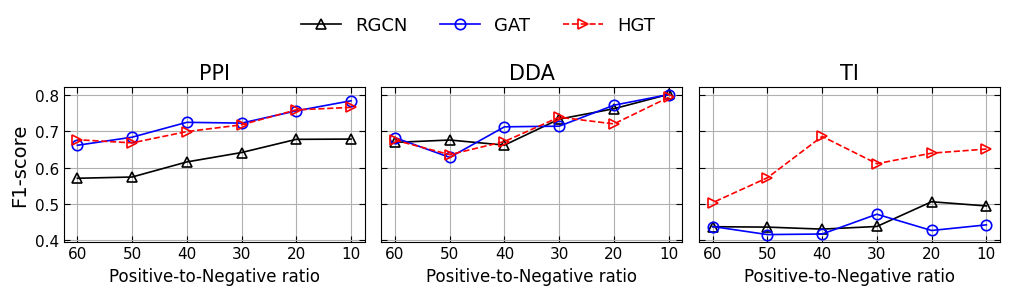

In [3]:
import os
import matplotlib.pyplot as plt
import numpy as np

# 1. 设置横坐标：不平衡比例
imbalance_levels = [10, 20, 30, 40, 50, 60]

# ===================== RGCN =====================
last_vals_m1_ppi = {
    "acc":      [0.753923, 0.794082, 0.794275, 0.794494, 0.790488, 0.801113],
    "macro_f1": [0.678047, 0.677308, 0.641151, 0.615358, 0.574019, 0.570596],
    "auc":      [0.883850, 0.879074, 0.864693, 0.877242, 0.866623, 0.854504],
    "ap":       [0.777700, 0.723642, 0.685483, 0.679271, 0.655683, 0.617480],
    "loss":     [126.373366, 81.351177, 106.041363, 102.117789, 100.975916, 89.154941],
    "neg_recall": [0.642361, 0.534247, 0.350000, 0.500000, 0.270833, 0.270833]
}
last_vals_m1_dda = {
    "acc":           [0.850100, 0.855106, 0.859083, 0.863045, 0.856001, 0.856079],
    "macro_f1":      [0.800679, 0.761237, 0.732782, 0.661500, 0.675452, 0.668972],
    "auc":           [0.935085, 0.935896, 0.930152, 0.933183, 0.918466, 0.926806],
    "ap":            [0.848033, 0.808644, 0.764524, 0.722649, 0.723660, 0.714080],
    "loss":          [69.959737, 65.546614, 67.271843, 50.727177, 69.876839, 70.546366],
    "neg_recall":    [0.669782, 0.491694, 0.401070, 0.167785, 0.222222, 0.214953]
}

last_vals_m1_ti = {
    "acc":           [0.637954, 0.644628, 0.658333, 0.649930, 0.658741, 0.663866],
    "macro_f1":      [0.494741, 0.506215, 0.438468, 0.431167, 0.436708, 0.437811],
    "auc":           [0.737363, 0.774246, 0.724124, 0.650239, 0.682249, 0.695788],
    "ap":            [0.549440, 0.551876, 0.521464, 0.488395, 0.483445, 0.488661],
    "loss":          [8.943782, 8.474524, 10.360910, 8.566569, 7.973482, 7.693915],
    "neg_recall":    [0.135135, 0.187500, 0.000000, 0.000000, 0.000000, 0.000000]
}

# ===================== GAT =====================
last_vals_m2_ppi = {
    "acc":      [0.828881, 0.827604, 0.837558, 0.841413, 0.842909, 0.836231],
    "macro_f1": [0.783063, 0.755388, 0.721822, 0.723967, 0.683221, 0.661032],
    "auc":      [0.932542, 0.935716, 0.922740, 0.892378, 0.895286, 0.878802],
    "ap":       [0.863005, 0.829797, 0.795816, 0.774350, 0.723311, 0.708348],
    "loss":     [19.675425, 23.878954, 20.275884, 23.508959, 18.947759, 23.941864],
    "neg_recall": [0.565972, 0.506849, 0.360000, 0.337838, 0.250000, 0.208333]
}
# last_vals_m2_dda = {
#     "acc":           [0.849331, 0.854712, 0.864961, 0.862328, 0.864236, 0.863527],
#     "macro_f1":      [0.778012, 0.768262, 0.696390, 0.632956, 0.708211, 0.643691],
#     "auc":           [0.946856, 0.948206, 0.947197, 0.947849, 0.944515, 0.947510],
#     "ap":            [0.859380, 0.822061, 0.781579, 0.773510, 0.751367, 0.755954],
#     "loss":          [24.069312, 22.843425, 21.973412, 20.496877, 21.891269, 20.887677],
#     "neg_recall":    [0.504673, 0.598007, 0.245989, 0.093960, 0.317460, 0.121495]
# }
last_vals_m2_dda = {
    "acc":           [0.850792, 0.855500, 0.862896, 0.863524, 0.863676, 0.856960],
    "macro_f1":      [0.800116, 0.770862, 0.713421, 0.711639, 0.627833, 0.681929],
    "auc":           [0.941937, 0.943799, 0.949857, 0.950850, 0.948923, 0.941091],
    "ap":            [0.855163, 0.817896, 0.790633, 0.799035, 0.755220, 0.732785],
    "loss":          [25.176914, 22.200357, 21.519212, 19.729374, 21.545201, 22.372052],
    "neg_recall":    [0.607477, 0.528239, 0.294118, 0.281879, 0.087302, 0.242991]
}
last_vals_m2_ti = {
    "acc":           [0.611036, 0.641873, 0.650000, 0.626220, 0.633566, 0.658263],
    "macro_f1":      [0.442847, 0.427424, 0.471994, 0.417774, 0.416245, 0.438285],
    "auc":           [0.700825, 0.708793, 0.707285, 0.634688, 0.690046, 0.629364],
    "ap":            [0.493895, 0.494588, 0.515778, 0.466603, 0.473264, 0.479759],
    "loss":          [5.216135, 4.911340, 5.280300, 4.721676, 4.632911, 4.057678],
    "neg_recall":    [0.054054, 0.000000, 0.062500, 0.000000, 0.000000, 0.000000]
}

# ===================== HGT =====================
last_vals_m3_ppi = {
    "acc":      [0.814524, 0.828288, 0.832385, 0.833449, 0.834751, 0.836579],
    "macro_f1": [0.764894, 0.758165, 0.717149, 0.698566, 0.667630, 0.676252],
    "auc":      [0.914472, 0.917198, 0.908359, 0.872762, 0.884474, 0.897763],
    "ap":       [0.839926, 0.817787, 0.766465, 0.739156, 0.707603, 0.728230],
    "loss":     [37.746875, 29.766673, 30.122461, 31.345964, 31.994255, 30.816424],
    "neg_recall": [0.545139, 0.575342, 0.400000, 0.472973, 0.270833, 0.250000]
}
last_vals_m3_dda = {
    "acc":           [0.836179, 0.825559, 0.845659, 0.836564, 0.851203, 0.843985],
    "macro_f1":      [0.792451, 0.719577, 0.738088, 0.671320, 0.635363, 0.675111],
    "auc":           [0.949547, 0.947061, 0.955335, 0.945588, 0.944693, 0.944381],
    "ap":            [0.867381, 0.809414, 0.789988, 0.743369, 0.731089, 0.728845],
    "loss":          [33.026719, 37.518156, 33.763608, 37.271640, 32.347720, 34.900171],
    "neg_recall":    [0.668224, 0.415282, 0.529412, 0.234899, 0.126984, 0.299065]
}
last_vals_m3_ti = {
    "acc":           [0.721400, 0.734160, 0.761111, 0.748954, 0.745455, 0.754902],
    "macro_f1":      [0.650657, 0.639467, 0.610580, 0.685405, 0.571993, 0.503816],
    "auc":           [0.859273, 0.881372, 0.889858, 0.864243, 0.807509, 0.827725],
    "ap":            [0.666668, 0.669540, 0.714247, 0.699016, 0.604530, 0.593119],
    "loss":          [4.528143, 4.104025, 3.790704, 4.184716, 4.103133, 3.413463],
    "neg_recall":    [0.459459, 0.562500, 0.187500, 0.454545, 0.142857, 0.000000]
}

# 只展示三个指标
# metrics = ["macro_f1", "auc", "ap"]

# rename = {
#     "macro_f1": "F1-score",
#     "auc": "ROC-AUC",
#     "ap": "PR-AUC"
# }
metrics = ["macro_f1"]

rename = {
    "macro_f1": "F1-score"
}
# 模仿示例图：颜色 + marker + 线型共同区分
# 指标用 marker / 线型区分；模型用颜色区分
# metric_style = {
#     "macro_f1": {
#         "marker": "^",
#         "linestyle": "-",
#         "markerfacecolor": "none"
#     },
#     "auc": {
#         "marker": "x",
#         "linestyle": ":",
#         "markerfacecolor": "none"
#     },
#     "ap": {
#         "marker": ">",
#         "linestyle": "--",
#         "markerfacecolor": "none"
#     }
# }

# model_colors = {
#     "RGCN": "black",
#     "GAT": "blue",
#     "HGT": "red"
# }
model_style = {
    "RGCN": {"color": "black", "marker": "^", "linestyle": "-"},
    "GAT":  {"color": "blue",  "marker": "o", "linestyle": "-"},
    "HGT":  {"color": "red",   "marker": ">", "linestyle": "--"},
}
# 按“模型 -> 数据集”组织
all_data = {
    "RGCN": {
        "PPI": last_vals_m1_ppi,
        "DDA": last_vals_m1_dda,
        "TI":  last_vals_m1_ti,
    },
    "GAT": {
        "PPI": last_vals_m2_ppi,
        "DDA": last_vals_m2_dda,
        "TI":  last_vals_m2_ti,
    },
    "HGT": {
        "PPI": last_vals_m3_ppi,
        "DDA": last_vals_m3_dda,
        "TI":  last_vals_m3_ti,
    }
}
def plot_f1_only(
    imbalance_levels,
    all_data,
    save_path="results/f1_only.pdf"
):
    x = np.array(imbalance_levels, dtype=float)
    models = ["RGCN", "GAT", "HGT"]
    datasets = ["PPI", "DDA", "TI"]
    metric = "macro_f1"

    plt.rcParams.update({
        "font.size": 12,
        "axes.labelweight": "normal",
        "axes.titleweight": "normal",
        "font.weight": "normal"
    })

    fig, axes = plt.subplots(
        1, 3,
        figsize=(10.8, 3.0),
        sharex=True,
        sharey=True
    )

    for j, dataset_name in enumerate(datasets):
        ax = axes[j]

        for model_name in models:
            style = model_style[model_name]
            y = all_data[model_name][dataset_name][metric]

            ax.plot(
                x,
                y,
                label=model_name,
                color=style["color"],
                linestyle=style["linestyle"],
                marker=style["marker"],
                linewidth=1.2,
                markersize=7.5,
                markerfacecolor="none",
                markeredgewidth=1.2
            )

        ax.set_title(dataset_name, fontsize=15, fontweight="normal")
        ax.set_xlabel("Positive-to-Negative ratio", fontsize=12, fontweight="normal")

        if j == 0:
            ax.set_ylabel("F1-score", fontsize=14, fontweight="normal")

        ax.grid(True)
        ax.invert_xaxis()
        ax.set_xticks(x)
        ax.tick_params(axis="both", labelsize=11, width=0.8, length=4, direction="in")
        ax.tick_params(top=True, right=True)

        for spine in ax.spines.values():
            spine.set_linewidth(0.8)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc="upper center",
        ncol=3,
        frameon=False,
        fontsize=13,
        bbox_to_anchor=(0.5, 1.05),
        handlelength=2.2,
        columnspacing=1.8
    )

    plt.tight_layout(rect=[0.05, 0.04, 1, 0.90], w_pad=1.0)

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, format="pdf", bbox_inches="tight")
    plt.show()


def plot_by_metric_rows(
    imbalance_levels,
    all_data,
    metrics=("macro_f1", "auc", "ap"),
    save_path="results/compact_metric_rows.pdf"
):
    x = np.array(imbalance_levels, dtype=float)
    models = ["RGCN", "GAT", "HGT"]
    datasets = ["PPI", "DDA", "TI"]

    plt.rcParams.update({
        "font.size": 12,
        "axes.labelweight": "normal",
        "axes.titleweight": "normal",
        "font.weight": "normal"
    })

    fig, axes = plt.subplots(
        1, 3,
        figsize=(10.8, 7.6),
        sharex=True,
        sharey="row"
    )

    for i, metric in enumerate(metrics):              # 每个指标一行
        for j, dataset_name in enumerate(datasets):   # 每个数据集一列
            ax = axes[i, j]

            for model_name in models:                 # 不同颜色区分模型
                style = model_style[model_name]
                y = all_data[model_name][dataset_name][metric]

                ax.plot(
                    x,
                    y,
                    label=model_name,
                    color=style["color"],
                    linestyle=style["linestyle"],
                    marker=style["marker"],
                    linewidth=1.2,
                    markersize=7.5,
                    markerfacecolor="none",
                    markeredgewidth=1.2
                )

            if i == 0:
                ax.set_title(dataset_name, fontsize=15, fontweight="normal")

            if j == 0:
                ax.set_ylabel(rename[metric], fontsize=14, fontweight="normal")

            if i == 2:
                ax.set_xlabel("Positive-to-Negative ratio", fontsize=12, fontweight="normal")

            ax.grid(True)
            ax.invert_xaxis()
            ax.set_xticks(x)
            ax.tick_params(axis="both", labelsize=11, width=0.8, length=4, direction="in")
            ax.tick_params(top=True, right=True)

            for spine in ax.spines.values():
                spine.set_linewidth(0.8)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc="upper center",
        ncol=3,
        frameon=False,
        fontsize=13,
        bbox_to_anchor=(0.5, 0.95),
        handlelength=2.2,
        columnspacing=1.8
    )

    plt.tight_layout(rect=[0.05, 0.04, 1, 0.90], w_pad=1.0, h_pad=1.0)

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, format="pdf", bbox_inches="tight")
    plt.show()

# plot_by_metric_rows(
#     imbalance_levels=imbalance_levels,
#     all_data=all_data,
#     metrics=metrics,
#     save_path=r"D:\Research\data\GARs+\GARpm\figs\3plus3results.pdf"
# )

plot_f1_only(
    imbalance_levels=imbalance_levels,
    all_data=all_data,
    save_path=r"D:\Research\data\GARs+\GARpm\figs\3plus3results.pdf"
)